<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Cross-Validation &amp; Backtest Overfitting
    </h1>
  </div>
</div>

In finance, labels overlap in time, so a naive train/test split **leaks** future
information into the training set and inflates backtest performance. This notebook
shows the RiskLabAI tools that fix this: **purged** K-Fold (with embargo),
**walk-forward**, and **Combinatorial Purged CV (CPCV)**, then quantifies
overfitting risk with the **Probability of Backtest Overfitting (PBO)**.

Reference: López de Prado, *Advances in Financial Machine Learning*, Ch. 7, 11–12.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({  # theme-adaptive figures: transparent bg + neutral-gray foreground
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "savefig.transparent": True,
    "text.color": "#888888", "axes.labelcolor": "#888888", "axes.titlecolor": "#888888",
    "axes.edgecolor": "#888888", "xtick.color": "#888888", "ytick.color": "#888888",
    "grid.color": "#888888", "grid.alpha": 0.3, "legend.framealpha": 0.0,
})
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

from RiskLabAI.features.feature_importance.generate_synthetic_data import get_test_dataset
from RiskLabAI.backtest.validation import KFold, PurgedKFold, WalkForward, CombinatorialPurged
from RiskLabAI.backtest.probability_of_backtest_overfitting import (
    probability_of_backtest_overfitting,
)

## 1. A labeled dataset with overlapping information

`get_test_dataset` builds a classification problem with known informative,
redundant, and noise features. We then declare that each label's information spans
~5 steps, so neighbouring samples overlap in time — exactly what purging must
remove. The `times` series maps each event's start (its index) to the end of its
information span (its value).

In [2]:
X, y, = get_test_dataset(n_features=10, n_informative=4, n_redundant=2,
                         n_samples=400, random_state=1)
n = len(X)

# Each label's information spans ~5 steps → neighbouring samples overlap.
starts = X.index
ends = starts[np.minimum(np.arange(n) + 5, n - 1)]
times = pd.Series(ends, index=starts)
print(f"dataset: {n} samples × {X.shape[1]} features")

dataset: 400 samples × 10 features


## 2. Purged K-Fold vs naive K-Fold

Purging drops overlapping training rows, so each purged fold trains on *fewer*,
cleaner samples than a naive fold.

In [3]:
purged = PurgedKFold(n_splits=5, times=times, embargo=0.02)
naive  = KFold(n_splits=5)

purged_splits = list(purged.split(X, y))
naive_splits  = list(naive.split(X, y))

pd.DataFrame({
    "fold":         range(1, 6),
    "naive_train":  [len(tr) for tr, _ in naive_splits],
    "purged_train": [len(tr) for tr, _ in purged_splits],
    "test":         [len(te) for _, te in purged_splits],
})

,fold,naive_train,purged_train,test
0,1,320,307,80
1,2,320,302,80
2,3,320,302,80
3,4,320,302,80
4,5,320,315,80


## 3. Walk-forward and Combinatorial Purged CV

Walk-forward grows the training window through time. CPCV instead recombines test
groups into **many** backtest paths — a far more robust estimate of out-of-sample
performance than a single split.

In [4]:
wf = WalkForward(n_splits=5)
wf_splits = list(wf.split(X))
print("walk-forward train sizes (growing):", [len(tr) for tr, _ in wf_splits])

cpcv = CombinatorialPurged(n_splits=6, n_test_groups=2, times=times, embargo=0.02)
print(f"CPCV: {cpcv.get_n_splits()} train/test splits → "
      f"{len(cpcv.backtest_paths(X))} backtest paths")

walk-forward train sizes (growing): [0, 80, 160, 240, 320]
CPCV: 15 train/test splits → 5 backtest paths


## 4. Scoring a model honestly

A random forest scored under purged CV reports a more honest accuracy than under
naive CV (which is optimistically biased by leakage). We feed the validator's
splits straight to scikit-learn, and tune hyper-parameters *through* the purged
validator the same way.

In [5]:
model = RandomForestClassifier(n_estimators=50, random_state=1)
naive_acc  = cross_val_score(model, X, y, cv=naive_splits,  scoring="accuracy")
purged_acc = cross_val_score(model, X, y, cv=purged_splits, scoring="accuracy")
print(f"CV accuracy — naive: {naive_acc.mean():.3f}   purged: {purged_acc.mean():.3f}")

grid = {"n_estimators": [20, 50], "max_depth": [3, 6]}
gs = GridSearchCV(RandomForestClassifier(random_state=1), grid,
                  cv=purged_splits, scoring="accuracy")
gs.fit(X, y)
print("grid-search best:", gs.best_params_, f"(CV score {gs.best_score_:.3f})")

CV accuracy — naive: 0.693   purged: 0.602


grid-search best: {'max_depth': 6, 'n_estimators': 20} (CV score 0.593)


## 5. Probability of Backtest Overfitting (PBO)

Suppose we try many strategy configurations and keep the in-sample best. PBO
estimates the probability the in-sample winner ranks below median out-of-sample, a
direct measure of overfitting risk. We feed it 50 skill-less (pure-noise)
strategies; the logit histogram shows where that winner lands out-of-sample.

PBO across 50 skill-less strategies: 0.655


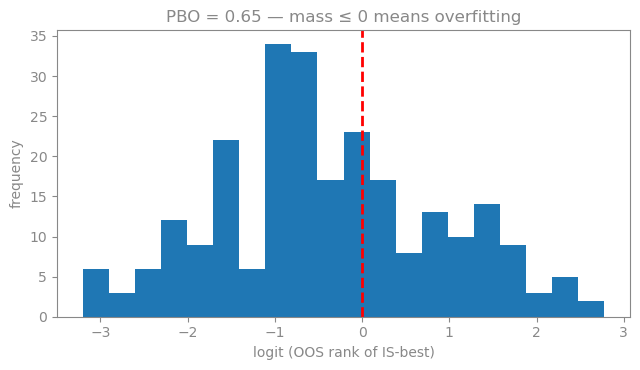

In [6]:
rng = np.random.default_rng(1)
T, N = 1000, 50
noise = rng.normal(0, 1, (T, N))          # 50 skill-less return streams

pbo, logits = probability_of_backtest_overfitting(noise, n_partitions=10)
print(f"PBO across {N} skill-less strategies: {pbo:.3f}")

plt.figure(figsize=(6.5, 3.8))
plt.hist(logits, bins=20)
plt.axvline(0.0, c="red", ls="--", lw=2)
plt.xlabel("logit (OOS rank of IS-best)"); plt.ylabel("frequency")
plt.title(f"PBO = {pbo:.2f} — mass ≤ 0 means overfitting")
plt.tight_layout(); plt.show()

## Takeaways

- Purging and embargo avoid leakage; purged folds train on fewer, cleaner samples.
- CPCV turns one fragile backtest into many paths.
- PBO puts a number on overfitting risk: an in-sample winner may not persist.

`get_test_dataset`, `KFold`, `PurgedKFold`, `WalkForward`, `CombinatorialPurged`,
and `probability_of_backtest_overfitting` all come from `RiskLabAI`; the validator
splits plug directly into scikit-learn.